# EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#users = pd.read_csv('raw_data/users.csv')
#fligths = pd.read_csv('raw_data/flights.csv')
#hotels = pd.read_csv('raw_data/hotels.csv')


# Sessions

In [15]:
sessions = pd.read_csv('data/raw_data/sessions.csv')

In [16]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,676570-f883c6e630f641cd9ca5ac61ae7045d5,676570,676570-ed23a4a861404b84b240ca68b9da1cb3,2023-03-27 19:37:00,2023-03-27 19:49:41,False,False,NaN,NaN,True,True,103,False
1,676707-f6b681d65ce44f4a9e895ad407ce3c79,676707,NaN,2023-03-27 19:05:00,2023-03-27 19:05:40,False,False,NaN,NaN,False,False,6,False
2,682247-ee2ef33c4dc6460fb15776d11f4a3cae,682247,NaN,2023-03-27 16:40:00,2023-03-27 16:40:45,False,False,NaN,NaN,False,False,6,False
3,684521-8e79dc4b20f24aecaea55a8084fbe4be,684521,NaN,2023-03-27 12:25:00,2023-03-27 12:26:19,False,False,NaN,NaN,False,False,11,False
4,684764-59c801395dec4aea939559ff4550bb34,684764,684764-584ca496c5ed4faca39b4fa85992c3c4,2023-03-27 04:23:00,2023-03-27 04:25:10,True,False,0.15,NaN,True,True,18,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,646455-e5ce3d55158a48d8afe821275001db38,646455,646455-1ed122d378a54ab69178c09405415dab,2023-03-27 18:17:00,2023-03-27 18:19:15,False,False,NaN,NaN,True,True,18,False
48679,656708-852b56ed84124df09fb6ddaf9b7fa2b3,656708,NaN,2023-03-27 20:07:00,2023-03-27 20:09:23,False,False,NaN,NaN,False,False,19,False
48680,659161-16f953ffd8304522a9a6372e844a7609,659161,659161-ec1633bb2b374247b9b93692a39ffbc6,2023-03-27 16:06:00,2023-03-27 16:09:34,False,False,NaN,NaN,True,True,29,False
48681,662750-7e4c81aca2fa4e2db2f4b96fad442b0e,662750,NaN,2023-03-27 13:45:00,2023-03-27 13:46:15,True,True,0.05,0.2,False,False,10,False


In [5]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 48683 entries, 0 to 48682
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              48683 non-null  str    
 1   user_id                 48683 non-null  int64  
 2   trip_id                 16778 non-null  str    
 3   session_start           48683 non-null  str    
 4   session_end             48683 non-null  str    
 5   flight_discount         48683 non-null  bool   
 6   hotel_discount          48683 non-null  bool   
 7   flight_discount_amount  8170 non-null   float64
 8   hotel_discount_amount   6183 non-null   float64
 9   flight_booked           48683 non-null  bool   
 10  hotel_booked            48683 non-null  bool   
 11  page_clicks             48683 non-null  int64  
 12  cancellation            48683 non-null  bool   
dtypes: bool(5), float64(2), int64(2), str(4)
memory usage: 3.2 MB


- discount columns has nan values, we can fill them.
- flight hotel discount überflüssig

In [6]:
sessions[~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)]

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
8476,101486-46912e06b8f94b949f46af20eb097f8f,101486,101486-29a51199b1a748da8c45d3d2fc9c691a,2022-03-26 20:08:22,2022-03-26 22:08:22,True,True,NaN,NaN,True,True,156,True
8477,118043-e476985728a741d7a96ea1dcf55963e6,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-04-22 09:38:27,2022-04-22 10:04:44.411729,True,True,NaN,NaN,True,True,26,True
8478,153982-0a2c4b9c37594cca8019068acedd878a,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-07-08 13:15:40,2022-07-08 14:20:35.612564,True,True,NaN,NaN,True,True,64,True
8479,174997-d37e4081489646fc891296f5e21b96f1,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2023-01-05 20:17:50,2023-01-05 22:17:50,True,True,NaN,NaN,True,True,155,True
8480,181157-4689176bf8e2444f928c77739c75c713,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-23 20:16:04,2022-05-23 22:16:04,True,True,NaN,NaN,True,True,200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33126,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
33127,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
33128,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
33129,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


In [7]:
sessions[["flight_discount", "hotel_discount"]]

,flight_discount,hotel_discount
0,False,False
1,False,False
2,False,False
3,False,False
4,True,False
...,...,...
48678,False,False
48679,False,False
48680,False,False
48681,True,True


In [8]:
~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)

array([False, False, False, ..., False, False, False], shape=(48683,))

In [9]:
sessions[~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)]

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
8476,101486-46912e06b8f94b949f46af20eb097f8f,101486,101486-29a51199b1a748da8c45d3d2fc9c691a,2022-03-26 20:08:22,2022-03-26 22:08:22,True,True,NaN,NaN,True,True,156,True
8477,118043-e476985728a741d7a96ea1dcf55963e6,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-04-22 09:38:27,2022-04-22 10:04:44.411729,True,True,NaN,NaN,True,True,26,True
8478,153982-0a2c4b9c37594cca8019068acedd878a,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-07-08 13:15:40,2022-07-08 14:20:35.612564,True,True,NaN,NaN,True,True,64,True
8479,174997-d37e4081489646fc891296f5e21b96f1,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2023-01-05 20:17:50,2023-01-05 22:17:50,True,True,NaN,NaN,True,True,155,True
8480,181157-4689176bf8e2444f928c77739c75c713,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-23 20:16:04,2022-05-23 22:16:04,True,True,NaN,NaN,True,True,200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33126,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
33127,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
33128,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
33129,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


In [26]:
sessions[~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)][["flight_discount", "hotel_discount", "flight_discount_amount", "hotel_discount_amount"]].drop_duplicates()

,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount
8476,True,True,NaN,NaN


In [11]:
sessions[["flight_discount_amount", "hotel_discount_amount"]].mean()

flight_discount_amount    0.139553
hotel_discount_amount     0.112065
dtype: float64

We are thinking on dropping the discount columns, since they are redundant. We wanted to proof the redundancy and found out that there is a discrepancy in the data. The discount columns are not always consistent with the discount amount columns. Never the less the only error are of the kind [True , True] -> [nan, nan]. We will substitue this ones with the mistakes with mean.

In [22]:
sessions[["flight_discount_amount", "hotel_discount_amount"]].mean()

flight_discount_amount    0.139553
hotel_discount_amount     0.112065
dtype: float64

In [25]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 48683 entries, 0 to 48682
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              48683 non-null  str    
 1   user_id                 48683 non-null  int64  
 2   trip_id                 16778 non-null  str    
 3   session_start           48683 non-null  str    
 4   session_end             48683 non-null  str    
 5   flight_discount         48683 non-null  bool   
 6   hotel_discount          48683 non-null  bool   
 7   flight_discount_amount  8170 non-null   float64
 8   hotel_discount_amount   6183 non-null   float64
 9   flight_booked           48683 non-null  bool   
 10  hotel_booked            48683 non-null  bool   
 11  page_clicks             48683 non-null  int64  
 12  cancellation            48683 non-null  bool   
dtypes: bool(5), float64(2), int64(2), str(4)
memory usage: 3.2 MB


In [24]:
sessions.loc[(sessions["flight_discount"]==True) & (sessions["hotel_discount"] == True) & (sessions["flight_discount_amount"].isna()) & (sessions["hotel_discount_amount"].isna()), ["flight_discount_amount", "hotel_discount_amount"]] = sessions[["flight_discount_amount", "hotel_discount_amount"]].mean()

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
8476,101486-46912e06b8f94b949f46af20eb097f8f,101486,101486-29a51199b1a748da8c45d3d2fc9c691a,2022-03-26 20:08:22,2022-03-26 22:08:22,True,True,NaN,NaN,True,True,156,True
8477,118043-e476985728a741d7a96ea1dcf55963e6,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-04-22 09:38:27,2022-04-22 10:04:44.411729,True,True,NaN,NaN,True,True,26,True
8478,153982-0a2c4b9c37594cca8019068acedd878a,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-07-08 13:15:40,2022-07-08 14:20:35.612564,True,True,NaN,NaN,True,True,64,True
8479,174997-d37e4081489646fc891296f5e21b96f1,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2023-01-05 20:17:50,2023-01-05 22:17:50,True,True,NaN,NaN,True,True,155,True
8480,181157-4689176bf8e2444f928c77739c75c713,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-23 20:16:04,2022-05-23 22:16:04,True,True,NaN,NaN,True,True,200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33126,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
33127,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
33128,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
33129,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


In [27]:
sessions.drop(columns=["flight_discount", "hotel_discount"], inplace=True)

In [28]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,676570-f883c6e630f641cd9ca5ac61ae7045d5,676570,676570-ed23a4a861404b84b240ca68b9da1cb3,2023-03-27 19:37:00,2023-03-27 19:49:41,NaN,NaN,True,True,103,False
1,676707-f6b681d65ce44f4a9e895ad407ce3c79,676707,NaN,2023-03-27 19:05:00,2023-03-27 19:05:40,NaN,NaN,False,False,6,False
2,682247-ee2ef33c4dc6460fb15776d11f4a3cae,682247,NaN,2023-03-27 16:40:00,2023-03-27 16:40:45,NaN,NaN,False,False,6,False
3,684521-8e79dc4b20f24aecaea55a8084fbe4be,684521,NaN,2023-03-27 12:25:00,2023-03-27 12:26:19,NaN,NaN,False,False,11,False
4,684764-59c801395dec4aea939559ff4550bb34,684764,684764-584ca496c5ed4faca39b4fa85992c3c4,2023-03-27 04:23:00,2023-03-27 04:25:10,0.15,NaN,True,True,18,False
...,...,...,...,...,...,...,...,...,...,...,...
48678,646455-e5ce3d55158a48d8afe821275001db38,646455,646455-1ed122d378a54ab69178c09405415dab,2023-03-27 18:17:00,2023-03-27 18:19:15,NaN,NaN,True,True,18,False
48679,656708-852b56ed84124df09fb6ddaf9b7fa2b3,656708,NaN,2023-03-27 20:07:00,2023-03-27 20:09:23,NaN,NaN,False,False,19,False
48680,659161-16f953ffd8304522a9a6372e844a7609,659161,659161-ec1633bb2b374247b9b93692a39ffbc6,2023-03-27 16:06:00,2023-03-27 16:09:34,NaN,NaN,True,True,29,False
48681,662750-7e4c81aca2fa4e2db2f4b96fad442b0e,662750,NaN,2023-03-27 13:45:00,2023-03-27 13:46:15,0.05,0.2,False,False,10,False


In [42]:
sessions[["flight_discount_amount", "hotel_discount_amount"]].count()

flight_discount_amount    8170
hotel_discount_amount     6183
dtype: int64

<Axes: >

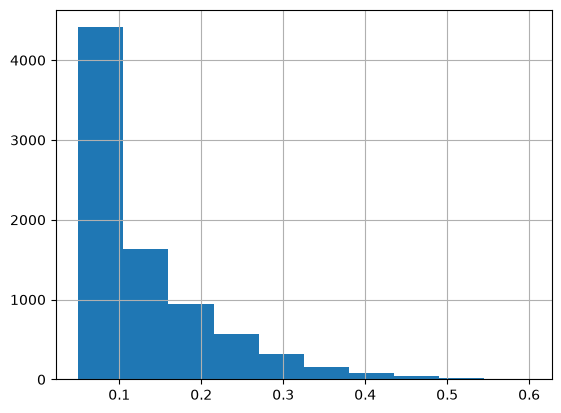

In [47]:
sessions["flight_discount_amount"].hist()

<Axes: >

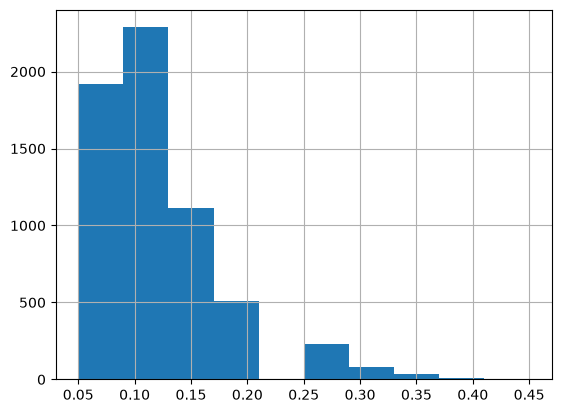

In [48]:
sessions["hotel_discount_amount"].hist()

In [29]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,676570-f883c6e630f641cd9ca5ac61ae7045d5,676570,676570-ed23a4a861404b84b240ca68b9da1cb3,2023-03-27 19:37:00,2023-03-27 19:49:41,NaN,NaN,True,True,103,False
1,676707-f6b681d65ce44f4a9e895ad407ce3c79,676707,NaN,2023-03-27 19:05:00,2023-03-27 19:05:40,NaN,NaN,False,False,6,False
2,682247-ee2ef33c4dc6460fb15776d11f4a3cae,682247,NaN,2023-03-27 16:40:00,2023-03-27 16:40:45,NaN,NaN,False,False,6,False
3,684521-8e79dc4b20f24aecaea55a8084fbe4be,684521,NaN,2023-03-27 12:25:00,2023-03-27 12:26:19,NaN,NaN,False,False,11,False
4,684764-59c801395dec4aea939559ff4550bb34,684764,684764-584ca496c5ed4faca39b4fa85992c3c4,2023-03-27 04:23:00,2023-03-27 04:25:10,0.15,NaN,True,True,18,False
...,...,...,...,...,...,...,...,...,...,...,...
48678,646455-e5ce3d55158a48d8afe821275001db38,646455,646455-1ed122d378a54ab69178c09405415dab,2023-03-27 18:17:00,2023-03-27 18:19:15,NaN,NaN,True,True,18,False
48679,656708-852b56ed84124df09fb6ddaf9b7fa2b3,656708,NaN,2023-03-27 20:07:00,2023-03-27 20:09:23,NaN,NaN,False,False,19,False
48680,659161-16f953ffd8304522a9a6372e844a7609,659161,659161-ec1633bb2b374247b9b93692a39ffbc6,2023-03-27 16:06:00,2023-03-27 16:09:34,NaN,NaN,True,True,29,False
48681,662750-7e4c81aca2fa4e2db2f4b96fad442b0e,662750,NaN,2023-03-27 13:45:00,2023-03-27 13:46:15,0.05,0.2,False,False,10,False


In [33]:
sessions.to_csv('data/preprocessed_data/sessions_preprocessed.csv', index=False)

In [34]:
sessions_preprocesed = pd.read_csv('data/preprocessed_data/sessions_preprocessed.csv')
sessions_preprocesed

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,676570-f883c6e630f641cd9ca5ac61ae7045d5,676570,676570-ed23a4a861404b84b240ca68b9da1cb3,2023-03-27 19:37:00,2023-03-27 19:49:41,NaN,NaN,True,True,103,False
1,676707-f6b681d65ce44f4a9e895ad407ce3c79,676707,NaN,2023-03-27 19:05:00,2023-03-27 19:05:40,NaN,NaN,False,False,6,False
2,682247-ee2ef33c4dc6460fb15776d11f4a3cae,682247,NaN,2023-03-27 16:40:00,2023-03-27 16:40:45,NaN,NaN,False,False,6,False
3,684521-8e79dc4b20f24aecaea55a8084fbe4be,684521,NaN,2023-03-27 12:25:00,2023-03-27 12:26:19,NaN,NaN,False,False,11,False
4,684764-59c801395dec4aea939559ff4550bb34,684764,684764-584ca496c5ed4faca39b4fa85992c3c4,2023-03-27 04:23:00,2023-03-27 04:25:10,0.15,NaN,True,True,18,False
...,...,...,...,...,...,...,...,...,...,...,...
48678,646455-e5ce3d55158a48d8afe821275001db38,646455,646455-1ed122d378a54ab69178c09405415dab,2023-03-27 18:17:00,2023-03-27 18:19:15,NaN,NaN,True,True,18,False
48679,656708-852b56ed84124df09fb6ddaf9b7fa2b3,656708,NaN,2023-03-27 20:07:00,2023-03-27 20:09:23,NaN,NaN,False,False,19,False
48680,659161-16f953ffd8304522a9a6372e844a7609,659161,659161-ec1633bb2b374247b9b93692a39ffbc6,2023-03-27 16:06:00,2023-03-27 16:09:34,NaN,NaN,True,True,29,False
48681,662750-7e4c81aca2fa4e2db2f4b96fad442b0e,662750,NaN,2023-03-27 13:45:00,2023-03-27 13:46:15,0.05,0.2,False,False,10,False


# Users

In [36]:
users = pd.read_csv('data/raw_data/users.csv')

In [37]:
users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10
...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06


In [38]:
pd.Timestamp.now()

Timestamp('2026-07-13 10:42:08.938106')

In [39]:
users["Age"] = ((pd.Timestamp.now() - pd.to_datetime(users["birthdate"]))/365.25).dt.days

In [40]:
users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,Age
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,45
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54
...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25,52
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27,47
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30,48
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06,47


<Axes: xlabel='Age', ylabel='Count'>

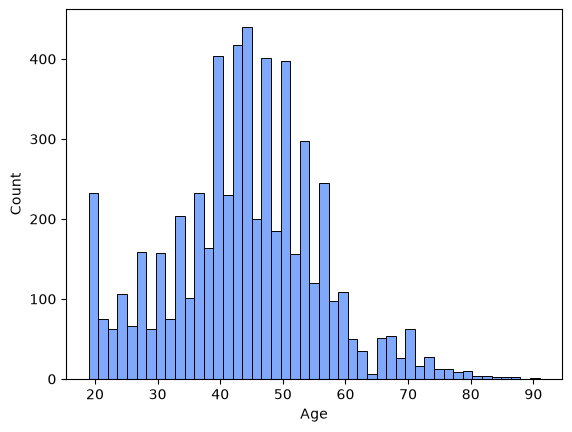

In [21]:
sns.histplot(users,x="Age")

<Axes: xlabel='Age'>

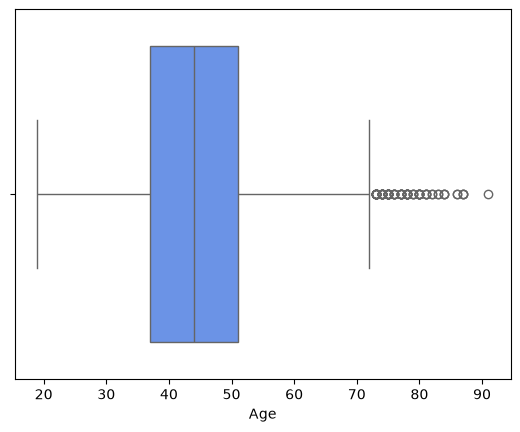

In [40]:
sns.boxplot(users,x="Age")

<Axes: xlabel='Age'>

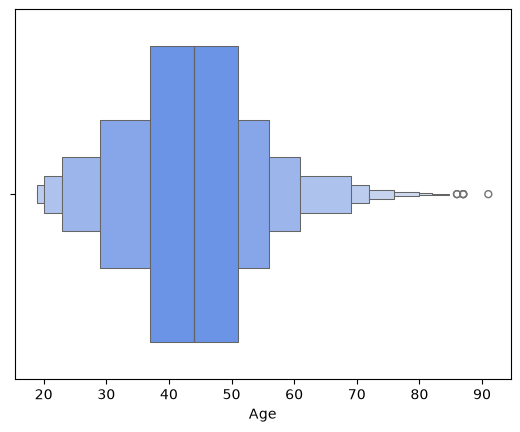

In [41]:
sns.boxenplot(users,x="Age")

<Axes: xlabel='Age', ylabel='Density'>

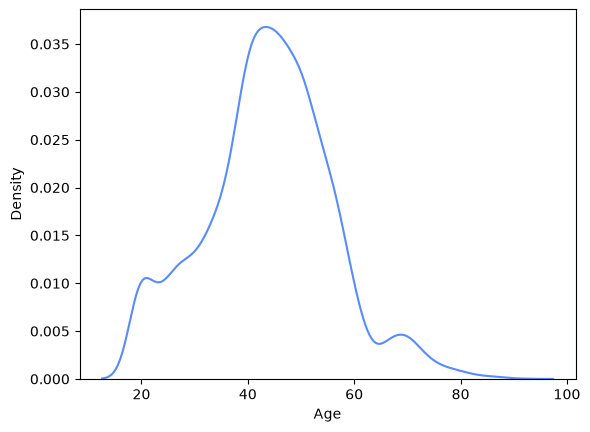

In [42]:
sns.kdeplot(users,x="Age")

In [22]:
users["home_country"].value_counts()

home_country
usa       4808
canada     974
Name: count, dtype: int64

In [23]:
users["home_city"].value_counts()

home_city
new york          657
los angeles       307
toronto           218
chicago           194
houston           179
                 ... 
modesto            14
burlington         13
newport news       13
spokane            13
salt lake city     12
Name: count, Length: 105, dtype: int64

In [25]:
users["gender"].value_counts(normalize=True)

gender
F    0.885161
M    0.112937
O    0.001902
Name: proportion, dtype: float64

In [41]:
users.to_csv('data/preprocessed_data/users_preprocessed.csv', index=False)

# Flights

In [42]:
flights = pd.read_csv('data/raw_data/flights.csv')

In [43]:
flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,522970-fa769adaa4364173a9a24f33b39ee1cf,ATL,vancouver,YVR,1,True,2023-03-15 11:00:00,2023-03-26 11:00:00,0,Korean Air,49.195,-123.182,613.07
1,536782-dd6a5a0600b04528ab9f94c73d6ef7a7,YQG,baltimore,BWI,1,True,2023-03-15 07:00:00,2023-03-18 07:00:00,1,AirTran Airways,39.175,-76.668,109.57
2,589259-b2f1378741d74d82a14a05f1a95106a1,LAX,new york,JFK,1,True,2023-03-14 08:00:00,2023-03-17 08:00:00,2,JetBlue Airways,40.640,-73.779,736.89
3,581577-26647a0bc1b642d6b5c9e5d4824f86de,PWM,edmonton,YXD,1,True,2023-03-15 10:00:00,2023-03-17 10:00:00,1,Delta Air Lines,53.667,-113.467,566.71
4,570625-840957fb34484d71bee7e6564fef0cc8,LGA,oklahoma city,TIK,3,True,2023-03-20 09:00:00,2023-03-22 09:00:00,0,American Airlines,35.393,-97.601,1114.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13762,624198-c5c7b4c8f5774191bc2ebb0d796c39e3,JFK,toronto,YTZ,1,True,2023-03-11 07:00:00,2023-03-22 07:00:00,1,Porter Airlines,43.862,-79.370,115.33
13763,572479-fb6a78a33b054425ba90a5319391fa2a,PWM,jacksonville,NCA,1,True,2023-03-12 16:00:00,2023-03-19 16:00:00,1,Ryanair,30.494,-81.688,285.30
13764,608287-6c767f7877af429eb60ca4c4491e4c92,DAL,montreal,YUL,1,True,2023-03-11 16:00:00,2023-03-13 16:00:00,1,Allegiant Air,45.517,-73.417,424.48
13765,635303-997e40b6c47e4bdf9ca4a81b15928afe,LAX,louisville,LOU,2,True,2023-03-12 07:00:00,2023-03-13 07:00:00,1,Ryanair,38.228,-85.664,905.34


In [29]:
flights["seats"].describe()

count    13767.000000
mean         1.200770
std          0.553873
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: seats, dtype: float64

In [32]:
flights["seats"].value_counts(normalize=True)

seats
1    0.852909
2    0.108012
3    0.027893
4    0.008934
5    0.001307
6    0.000799
7    0.000073
8    0.000073
Name: proportion, dtype: float64

<Axes: xlabel='seats', ylabel='Count'>

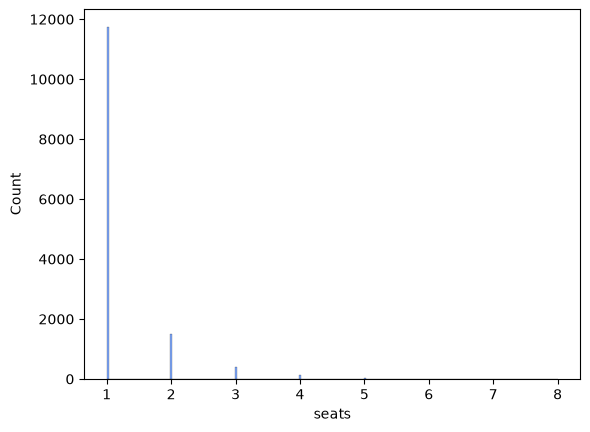

In [28]:
sns.histplot(flights, x="seats")

In [33]:
flights["return_flight_booked"].value_counts(normalize=True)

return_flight_booked
True     0.956781
False    0.043219
Name: proportion, dtype: float64

In [36]:
flights.groupby("destination")["destination_airport"].count().sort_values(ascending=False)

destination
new york       1943
los angeles    1023
toronto         734
chicago         706
houston         566
               ... 
mexico city       1
riyadh            1
pune              1
punta cana        1
sydney            1
Name: destination_airport, Length: 125, dtype: int64

In [37]:
flights.groupby(["origin_airport", "destination"])["destination_airport"].count().sort_values(ascending=False)

origin_airport  destination
LAX             new york       124
JFK             los angeles     83
LGA             los angeles     69
                toronto         53
JFK             toronto         49
                              ... 
ATL             calgary          1
                charlotte        1
ANC             las vegas        1
                montreal         1
                nashville        1
Name: destination_airport, Length: 4437, dtype: int64

<Axes: xlabel='base_fare_usd', ylabel='Count'>

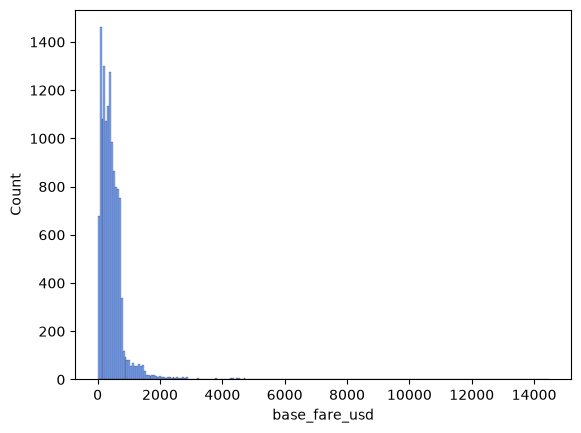

In [38]:
sns.histplot(flights, x="base_fare_usd")

<Axes: xlabel='base_fare_usd'>

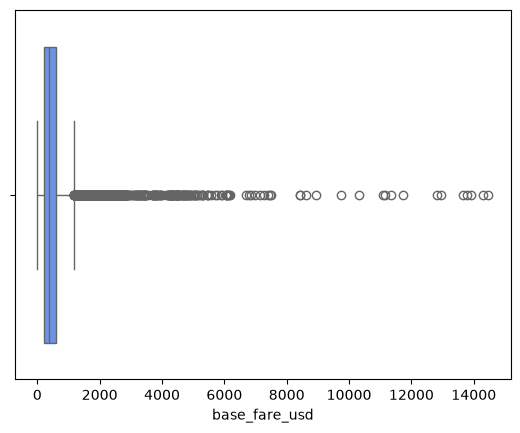

In [39]:
sns.boxplot(flights, x="base_fare_usd")

In [45]:
flights.to_csv('data/preprocessed_data/flights_preprocessed.csv', index=False)

# Hotels

In [46]:
hotels = pd.read_csv('data/raw_data/hotels.csv')

In [47]:
hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,379543-786b5bc990ab42348075f170807f4625,Four Seasons - tucson,1,1,2022-11-04 16:27:07.02,2022-11-06 11:00:00,289
1,408551-35b342c868fa4dcfae23554edc29491e,Extended Stay - new york,3,2,2022-11-20 15:29:05.775,2022-11-24 11:00:00,304
2,417679-624d84164bc443e6bfc876d4a84d358c,Hyatt - louisville,2,3,2022-11-26 10:18:43.83,2022-11-28 11:00:00,400
3,416319-1b7b31b88d834e94813e68865cbc87cf,NH Hotel - phoenix,2,1,2022-12-03 18:20:46.995,2022-12-06 11:00:00,107
4,426478-9e3f1753141b4c3c82d3164029d2eecb,Shangri-La - detroit,14,1,2023-01-18 09:19:52.005,2023-02-01 11:00:00,100
...,...,...,...,...,...,...,...
14369,528735-40ab1cc1756745c1814b683d2af2e07c,Rosewood - toronto,0,2,2023-07-28 17:02:59.55,2023-07-29 11:00:00,224
14370,675594-084fb7964a664f1593002725d0ebce57,Fairmont - houston,2,1,2023-07-25 14:24:00.36,2023-07-28 11:00:00,84
14371,638580-a26a38d6775d4d1ca59a0e4a6816c4d1,Wyndham - new york,7,1,2023-07-22 11:00:00,2023-07-29 11:00:00,119
14372,653640-0f7354c3dc7341899c2097b2cb38049d,Conrad - paris,10,1,2024-03-02 05:12:13.455,2024-03-12 11:00:00,184


<Axes: xlabel='hotel_per_room_usd', ylabel='Count'>

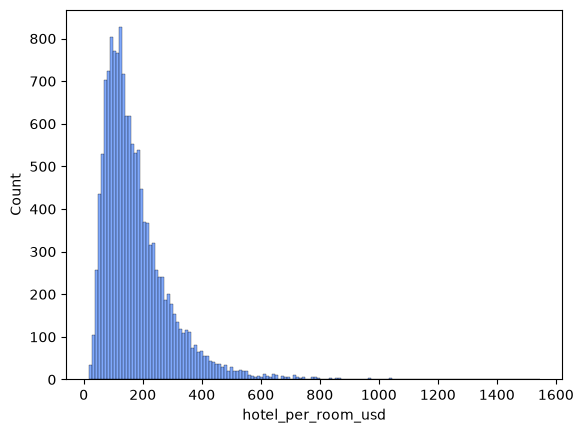

In [48]:
sns.histplot(hotels["hotel_per_room_usd"])

In [83]:
hotels["hotel_per_room_usd"].describe()

count    14374.000000
mean       178.189648
std        119.597469
min         17.000000
25%         99.000000
50%        148.000000
75%        223.000000
max       1545.000000
Name: hotel_per_room_usd, dtype: float64

<Axes: xlabel='nights', ylabel='Count'>

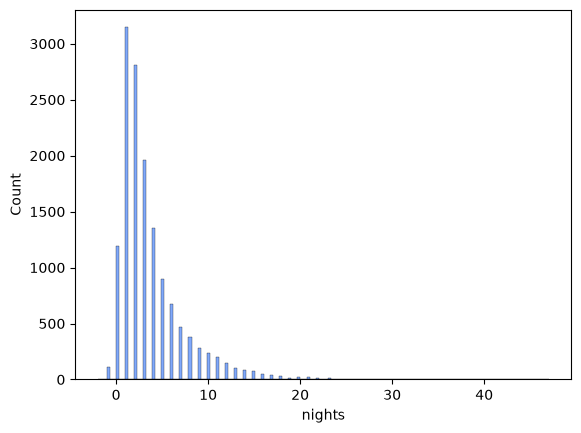

In [84]:
sns.histplot(hotels,x="nights")

In [85]:
hotels["nights"].describe()

count    14374.000000
mean         3.649158
std          3.830505
min         -2.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         47.000000
Name: nights, dtype: float64

In [86]:
hotels.columns

Index(['trip_id', 'hotel_name', 'nights', 'rooms', 'check_in_time',
       'check_out_time', 'hotel_per_room_usd'],
      dtype='str')

In [49]:
hotels["check_in_time"] = pd.to_datetime(hotels["check_in_time"], format='mixed')
hotels["check_out_time"] = pd.to_datetime(hotels["check_out_time"], format='mixed')

In [50]:
hotels["checkin_weekday"] = hotels["check_in_time"].dt.day_name()
hotels["checkout_weekday"] = hotels["check_out_time"].dt.day_name()

In [51]:
hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,checkin_weekday,checkout_weekday
0,379543-786b5bc990ab42348075f170807f4625,Four Seasons - tucson,1,1,2022-11-04 16:27:07.020,2022-11-06 11:00:00,289,Friday,Sunday
1,408551-35b342c868fa4dcfae23554edc29491e,Extended Stay - new york,3,2,2022-11-20 15:29:05.775,2022-11-24 11:00:00,304,Sunday,Thursday
2,417679-624d84164bc443e6bfc876d4a84d358c,Hyatt - louisville,2,3,2022-11-26 10:18:43.830,2022-11-28 11:00:00,400,Saturday,Monday
3,416319-1b7b31b88d834e94813e68865cbc87cf,NH Hotel - phoenix,2,1,2022-12-03 18:20:46.995,2022-12-06 11:00:00,107,Saturday,Tuesday
4,426478-9e3f1753141b4c3c82d3164029d2eecb,Shangri-La - detroit,14,1,2023-01-18 09:19:52.005,2023-02-01 11:00:00,100,Wednesday,Wednesday
...,...,...,...,...,...,...,...,...,...
14369,528735-40ab1cc1756745c1814b683d2af2e07c,Rosewood - toronto,0,2,2023-07-28 17:02:59.550,2023-07-29 11:00:00,224,Friday,Saturday
14370,675594-084fb7964a664f1593002725d0ebce57,Fairmont - houston,2,1,2023-07-25 14:24:00.360,2023-07-28 11:00:00,84,Tuesday,Friday
14371,638580-a26a38d6775d4d1ca59a0e4a6816c4d1,Wyndham - new york,7,1,2023-07-22 11:00:00.000,2023-07-29 11:00:00,119,Saturday,Saturday
14372,653640-0f7354c3dc7341899c2097b2cb38049d,Conrad - paris,10,1,2024-03-02 05:12:13.455,2024-03-12 11:00:00,184,Saturday,Tuesday


In [59]:
hotels["checkin_weekday"].value_counts()

checkin_weekday
Friday       2114
Sunday       2066
Thursday     2055
Tuesday      2050
Wednesday    2040
Saturday     2038
Monday       2011
Name: count, dtype: int64

In [60]:
hotels["checkout_weekday"].value_counts()

checkout_weekday
Saturday     2132
Tuesday      2118
Sunday       2047
Thursday     2037
Friday       2021
Monday       2011
Wednesday    2008
Name: count, dtype: int64

In [100]:
hotels["check_out_time"]

0       2022-11-06 11:00:00
1       2022-11-24 11:00:00
2       2022-11-28 11:00:00
3       2022-12-06 11:00:00
4       2023-02-01 11:00:00
                ...        
14369   2023-07-29 11:00:00
14370   2023-07-28 11:00:00
14371   2023-07-29 11:00:00
14372   2024-03-12 11:00:00
14373   2023-08-06 11:00:00
Name: check_out_time, Length: 14374, dtype: datetime64[us]

In [52]:
hotels["nights"] = (pd.to_datetime(hotels["check_out_time"].dt.date) - pd.to_datetime(hotels["check_in_time"].dt.date)).dt.days

In [53]:
hotels[hotels["nights"]==0]

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,checkin_weekday,checkout_weekday
24,476714-f7d36ece6b46409cbe363123d363bd40,Banyan Tree - oklahoma city,0,2,2023-01-15 11:44:13.425,2023-01-15 11:00:00,294,Sunday,Sunday
57,541382-454e9e721f3b4f9ba02663b53eba5c2f,Starwood - nashville,0,1,2023-02-01 10:32:13.965,2023-02-01 11:00:00,138,Wednesday,Wednesday
59,543375-efb4583e75d04219b05d9a3b314dd59e,Wyndham - dallas,0,1,2023-01-31 11:30:05.490,2023-01-31 11:00:00,116,Tuesday,Tuesday
74,418692-8807eff31195420d9661f4668aeb1965,Radisson - milwaukee,0,3,2023-02-02 10:44:47.985,2023-02-02 11:00:00,123,Thursday,Thursday
90,562886-56c06ef71df34257ad92c4af48227fd8,Aman Resorts - los angeles,0,1,2023-02-05 12:40:44.535,2023-02-05 11:00:00,127,Sunday,Sunday
...,...,...,...,...,...,...,...,...,...
14149,551834-336ecdfce2df4b34bded6fb6f55e4327,Best Western - new york,0,1,2023-03-24 09:51:09.945,2023-03-24 11:00:00,516,Friday,Friday
14260,532535-e3714d8822254983b80006cb7f3b9833,Starwood - san diego,0,1,2023-05-18 09:13:17.265,2023-05-18 11:00:00,110,Thursday,Thursday
14267,530385-3f939903aa7e4e60a64b6100bb0a7686,Marriott - toronto,0,1,2023-05-25 09:52:41.655,2023-05-25 11:00:00,126,Thursday,Thursday
14302,663376-46af43d271934e719e0a95c74692c14c,Marriott - columbus,0,1,2023-06-14 11:00:27.360,2023-06-14 11:00:00,144,Wednesday,Wednesday


In [60]:
hotels["nights"].value_counts()

nights
2     3166
3     2569
1     2195
4     1834
5     1232
6      844
7      592
8      412
9      345
10     255
11     215
12     177
13     104
14      95
15      76
16      56
17      43
18      41
20      24
21      19
22      14
19      10
23       8
24       6
25       5
26       5
29       4
28       4
27       4
30       3
34       3
35       2
31       2
32       2
38       2
36       1
33       1
42       1
40       1
47       1
43       1
Name: count, dtype: int64

## I cheat and say nights with < 1 are 1 night stays. This is a data error, but we will not investigate it further.

In [59]:
hotels.loc[hotels["nights"]<1, "nights"] = 1

In [117]:
a = hotels.groupby(["checkin_weekday", "nights"])["nights"].count().sort_values(ascending=False)

In [61]:
hotels.to_csv('data/preprocessed_data/hotels_preprocessed.csv', index=False)